In [1]:
print("hello world")

hello world


In [2]:
import pandas as pd
import numpy as np 

In [3]:
df=pd.read_csv("Admission_Predict.csv")

In [4]:
df.sample(10)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
145,146,320,113,2,2.0,2.5,8.64,1,0.81
121,122,334,119,5,4.5,4.5,9.48,1,0.94
216,217,322,112,4,4.5,4.5,9.26,1,0.91
51,52,312,100,2,1.5,3.5,7.90,1,0.56
170,171,312,101,2,2.5,3.5,8.04,1,0.68
63,64,315,107,2,4.0,3.0,8.50,1,0.56
374,375,315,105,2,2.0,2.5,7.65,0,0.39
175,176,320,111,4,4.5,3.5,8.87,1,0.85
37,38,300,105,1,1.0,2.0,7.80,0,0.58
317,318,300,99,1,1.0,2.5,8.01,0,0.58


In [5]:
df.shape

(400, 9)

In [7]:
df.drop(columns=["Serial No."],inplace=True)

In [8]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
x=df.iloc[:,0:6]
y=df["Chance of Admit "]
y


0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
395    0.82
396    0.84
397    0.91
398    0.67
399    0.95
Name: Chance of Admit , Length: 400, dtype: float64

In [74]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2)

In [45]:
x_train

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA
300,309,106,2,2.5,2.5,8.00
175,320,111,4,4.5,3.5,8.87
229,324,111,4,3.0,3.0,9.01
200,317,103,3,2.5,3.0,8.54
354,297,98,2,2.5,3.0,7.67
...,...,...,...,...,...,...
104,326,112,3,3.5,3.0,9.05
337,332,118,5,5.0,5.0,9.47
87,317,107,2,3.5,3.0,8.28
185,327,113,4,4.5,4.5,9.11


In [75]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [76]:
import torch 
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader
import matplotlib.pyplot as plt


In [77]:
x_test_scaled.shape[0]

80

In [78]:
X_train = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_test  = torch.tensor(x_test_scaled, dtype=torch.float32)
y_test  = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)


In [79]:
X_test.shape[0]


80

In [80]:
train_ds = TensorDataset(X_train, y_train)
test_ds  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)


In [56]:
X_train

tensor([[0.3800, 0.4815, 0.2500, 0.3750, 0.3750, 0.3859],
        [0.6000, 0.6667, 0.7500, 0.8750, 0.6250, 0.6656],
        [0.6800, 0.6667, 0.7500, 0.5000, 0.5000, 0.7106],
        ...,
        [0.5400, 0.5185, 0.2500, 0.6250, 0.5000, 0.4759],
        [0.7400, 0.7407, 0.7500, 0.8750, 0.8750, 0.7428],
        [0.2200, 0.5185, 0.5000, 0.6250, 0.6250, 0.4952]])

In [86]:
class RegressionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6,7),
            nn.ReLU(),
            nn.Linear(7,7),
            nn.ReLU(),
            nn.Linear(7,1)
        )
    def forward(self,x):
        return self.net(x)
        
model = RegressionMLP()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [87]:
epochs = 50
train_losses = []
test_losses = []

for epoch in range(epochs):
    
    # --- TRAIN ---
    model.train()
    running_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    
    # --- TEST ---
    model.eval()
    test_running_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb)
            loss = criterion(preds, yb)
            test_running_loss += loss.item()
    
    test_loss = test_running_loss / len(test_loader)
    test_losses.append(test_loss)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

    

Epoch 1/50 | Train Loss: 0.2262 | Test Loss: 0.2073
Epoch 2/50 | Train Loss: 0.1997 | Test Loss: 0.1827
Epoch 3/50 | Train Loss: 0.1741 | Test Loss: 0.1576
Epoch 4/50 | Train Loss: 0.1471 | Test Loss: 0.1306
Epoch 5/50 | Train Loss: 0.1187 | Test Loss: 0.1025
Epoch 6/50 | Train Loss: 0.0899 | Test Loss: 0.0750
Epoch 7/50 | Train Loss: 0.0629 | Test Loss: 0.0499
Epoch 8/50 | Train Loss: 0.0398 | Test Loss: 0.0300
Epoch 9/50 | Train Loss: 0.0228 | Test Loss: 0.0168
Epoch 10/50 | Train Loss: 0.0126 | Test Loss: 0.0093
Epoch 11/50 | Train Loss: 0.0074 | Test Loss: 0.0061
Epoch 12/50 | Train Loss: 0.0059 | Test Loss: 0.0052
Epoch 13/50 | Train Loss: 0.0056 | Test Loss: 0.0050
Epoch 14/50 | Train Loss: 0.0056 | Test Loss: 0.0049
Epoch 15/50 | Train Loss: 0.0056 | Test Loss: 0.0049
Epoch 16/50 | Train Loss: 0.0055 | Test Loss: 0.0050
Epoch 17/50 | Train Loss: 0.0055 | Test Loss: 0.0050
Epoch 18/50 | Train Loss: 0.0055 | Test Loss: 0.0050
Epoch 19/50 | Train Loss: 0.0054 | Test Loss: 0.0050
Ep

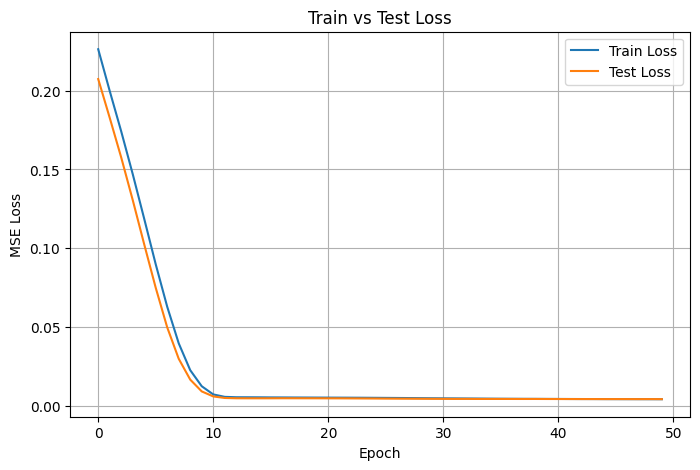

In [91]:


plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Train vs Test Loss")
plt.legend()
plt.grid(True)
plt.show()

